<a href="https://colab.research.google.com/github/wcliao1962/2025_DL/blob/master/Keras_Imdb_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 下載IMDb

* 執行下載前，請先在Colab虛擬機**建立data資料夾** (點選Files圖示(最右邊)，在Files頁面上，按滑鼠右鍵，點選New folder)


In [1]:
import urllib.request
import os
import tarfile

In [2]:
url="http://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
filepath="data/aclImdb_v1.tar.gz"
if not os.path.isfile(filepath):
    result=urllib.request.urlretrieve(url,filepath)
    print('downloaded:',result)

downloaded: ('data/aclImdb_v1.tar.gz', <http.client.HTTPMessage object at 0x7b51318b0490>)


# 解壓縮IMDb：在data/aclImdb當中

In [3]:
if not os.path.exists("data/aclImdb"):
    tfile = tarfile.open("data/aclImdb_v1.tar.gz", 'r:gz')
    result=tfile.extractall('data/')

# 檢視data/aclImdb內的資料夾結構(解壓縮後)：
* **test** (影評25000篇，測試用)
  * **neg**: 有12500篇負面影評文字檔
  * **pos**: 有12500篇正面影評文字檔
* **train** (影評25000篇，訓練用)
  * **neg**: 有12500篇負面影評文字檔
  * **pos**: 有12500篇正面影評文字檔


# 匯入文字資料預處理模組

In [4]:
# from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.preprocessing.text import Tokenizer

# 定義rm_tags(text)函數
用以去除text當中的HTML標籤(tag)

In [5]:
import re
def rm_tags(text):
    re_tag = re.compile(r'<[^>]+>')
    return re_tag.sub('', text)

# 定義 read_files(filetype)函數
* filetype可以是train或test
* 是train，則由data/aclImdb的train資料夾**讀取訓練資料**
* 是test，則由test資料夾**讀取測試資料**


In [6]:
import os
def read_files(filetype):
    path = "data/aclImdb/"
    file_list=[]

    positive_path=path + filetype+"/pos/"
    for f in os.listdir(positive_path):
        file_list+=[positive_path+f]

    negative_path=path + filetype+"/neg/"
    for f in os.listdir(negative_path):
        file_list+=[negative_path+f]

    print('read',filetype, 'files:',len(file_list))

    all_labels = ([1] * 12500 + [0] * 12500)

    all_texts  = []
    for fi in file_list:
        with open(fi,encoding='utf8') as file_input:
            all_texts += [rm_tags(" ".join(file_input.readlines()))]

    return all_labels,all_texts

# 建立訓練與測試資料

In [7]:
y_train,train_text=read_files("train")

read train files: 25000


In [8]:
y_test,test_text=read_files("test")

read test files: 25000


In [ ]:
#查看正面評價的影評

In [9]:
train_text[0]

'Wow. What a wonderful film. The script is nearly perfect it appears this is the only film written by Minglun Wei,I hope he has more stories in him.The acting is sublime. Renying Zhou as Doggie was amazing -- very natural talent, and Xu Zhu was a delight - very believable as the jaded old traditionalist. The soundtrack was very effective, guiding without being overwhelming. If only more movies like this were made whether in Hollywood or Hong Kong- a family friendly, well acted, well written, well directed, near perfect gem.'

In [10]:
y_train[0]

1

In [ ]:
#查看負面評價的影評

In [11]:
train_text[12500]

"I had to do a search on the actresses to find the board of this film because the title is now An Unexpected Love. It's not really worth looking for but I was unfamiliar with both leads and wondered why they were headlining a lesbian flick on Lifetime. Everything's pretty restrained and you don't really get an idea of who these characters are so, as a viewer, I wasn't able to become emotionally invested in the storyline. I guess I'm not the target audience for this but I'm not sure who is. Everything's muted and soft focus and earth tones...nothing's very interesting. I had a prurient interest in seeing two women make out but it's handled so discreetly that I was disappointed. Rent Personal Best instead."

In [12]:
y_train[12500]

0

# 建立字典：
* 字典的數量限制為2000：nb_words=2000
* 讀取訓練資料所有影評(train_text)，依每一個**英文單字(word)**在訓練資料(所有影評文章)出現頻率排序，取最高前2000個單字及其順序數字(index)，形成一個字典
* 字典內容類似如下：{'the': 1, 'and': 2, 'a': 3, 'of': 4, 'to': 5, 'is': 6, 'in': 7, 'it': 8, ... }

In [21]:
tokens = Tokenizer(num_words=2000)
tokens.fit_on_texts(train_text)

In [22]:
print(tokens.document_count)

25000


In [23]:
# 列出字典所有內容(全部2000項非常多)，建議可以列出，但上傳GitHub時，記得先清除掉outputs
print(tokens.word_index)

{'the': 1, 'and': 2, 'a': 3, 'of': 4, 'to': 5, 'is': 6, 'in': 7, 'it': 8, 'i': 9, 'this': 10, 'that': 11, 'was': 12, 'as': 13, 'for': 14, 'with': 15, 'movie': 16, 'but': 17, 'film': 18, 'on': 19, 'not': 20, 'you': 21, 'are': 22, 'his': 23, 'have': 24, 'be': 25, 'he': 26, 'one': 27, 'all': 28, 'at': 29, 'by': 30, 'an': 31, 'they': 32, 'who': 33, 'so': 34, 'from': 35, 'like': 36, 'her': 37, 'or': 38, 'just': 39, 'about': 40, "it's": 41, 'out': 42, 'has': 43, 'if': 44, 'some': 45, 'there': 46, 'what': 47, 'good': 48, 'more': 49, 'when': 50, 'very': 51, 'up': 52, 'no': 53, 'time': 54, 'she': 55, 'even': 56, 'my': 57, 'would': 58, 'which': 59, 'only': 60, 'story': 61, 'really': 62, 'see': 63, 'their': 64, 'had': 65, 'can': 66, 'were': 67, 'me': 68, 'well': 69, 'than': 70, 'we': 71, 'much': 72, 'been': 73, 'get': 74, 'bad': 75, 'will': 76, 'also': 77, 'do': 78, 'into': 79, 'people': 80, 'other': 81, 'first': 82, 'great': 83, 'because': 84, 'how': 85, 'him': 86, 'most': 87, "don't": 88, 'made

In [16]:
# 列出字典前100項，但需將字典轉換成list，方便選出前100項

# Convert the dictionary to a list of (word, index) pairs
word_index_items = list(tokens.word_index.items())

# Print the first 100 items
print(word_index_items[:100])

[('the', 1), ('and', 2), ('a', 3), ('of', 4), ('to', 5), ('is', 6), ('in', 7), ('it', 8), ('i', 9), ('this', 10), ('that', 11), ('was', 12), ('as', 13), ('for', 14), ('with', 15), ('movie', 16), ('but', 17), ('film', 18), ('on', 19), ('not', 20), ('you', 21), ('are', 22), ('his', 23), ('have', 24), ('be', 25), ('he', 26), ('one', 27), ('all', 28), ('at', 29), ('by', 30), ('an', 31), ('they', 32), ('who', 33), ('so', 34), ('from', 35), ('like', 36), ('her', 37), ('or', 38), ('just', 39), ('about', 40), ("it's", 41), ('out', 42), ('has', 43), ('if', 44), ('some', 45), ('there', 46), ('what', 47), ('good', 48), ('more', 49), ('when', 50), ('very', 51), ('up', 52), ('no', 53), ('time', 54), ('she', 55), ('even', 56), ('my', 57), ('would', 58), ('which', 59), ('only', 60), ('story', 61), ('really', 62), ('see', 63), ('their', 64), ('had', 65), ('can', 66), ('were', 67), ('me', 68), ('well', 69), ('than', 70), ('we', 71), ('much', 72), ('been', 73), ('get', 74), ('bad', 75), ('will', 76), ('

# 轉換每篇影評(文字串)為一連串的數字(數字串)
* 每篇影評所有**單字(word)**轉換為一個一個的數字(index)
* **注意：只有在字典當中的單字才會被轉換為數字，若無略過**

In [24]:
x_train_seq = tokens.texts_to_sequences(train_text)
x_test_seq  = tokens.texts_to_sequences(test_text)

In [25]:
print(train_text[0])

Wow. What a wonderful film. The script is nearly perfect it appears this is the only film written by Minglun Wei,I hope he has more stories in him.The acting is sublime. Renying Zhou as Doggie was amazing -- very natural talent, and Xu Zhu was a delight - very believable as the jaded old traditionalist. The soundtrack was very effective, guiding without being overwhelming. If only more movies like this were made whether in Hollywood or Hong Kong- a family friendly, well acted, well written, well directed, near perfect gem.


In [26]:
print(x_train_seq[0])

[1315, 47, 3, 385, 18, 1, 225, 6, 750, 399, 8, 734, 10, 6, 1, 60, 18, 394, 30, 9, 436, 26, 43, 49, 533, 7, 86, 1, 112, 6, 13, 12, 476, 51, 1244, 671, 2, 12, 3, 3021, 51, 860, 13, 1, 150, 1, 809, 12, 51, 1126, 205, 108, 44, 60, 49, 98, 36, 10, 67, 89, 722, 7, 358, 38, 2574, 1980, 3, 219, 2565, 69, 914, 69, 394, 69, 522, 746, 399, 1524]


In [27]:
# sequences_to_texts() 可以轉換數字為文字
tokens.sequences_to_texts([[10, 6, 3, 16, 11, 210, 124, 253, 54, 9, 63, 8, 46, 22, 34]])

['this is a movie that gets better each time i see it there are so']

# 完成x_train與x_test的建立：使每篇影評的數字串長度相同

* 每篇影評數字串的數字個數(長度)，因每篇影評內的單字個數不同而不同
* 進行神經網路的訓練時，每一篇影評的數字串長度必須相同
* 數字串長度過長，裁減數字，過短，則補數字0
* 程式碼當中：maxlen=100，使每一篇文章的數字串長度都成為100
* 如果影評轉成數字串，長度大於100，pad_sequences處理後，會截掉(truncate)數字串**前面**的數字
* 如果影評轉成數字串，長度不足100，pad_sequences處理後，數字串**前面**會加上0

In [28]:
x_train = sequence.pad_sequences(x_train_seq, maxlen=380)
x_test  = sequence.pad_sequences(x_test_seq,  maxlen=380)

In [ ]:
#如果文章轉成數字不足100,pad_sequences處理後，前面會加上0

In [29]:
print('before pad_sequences length=',len(x_train_seq[0]))
print(x_train_seq[0])

before pad_sequences length= 78
[1315, 47, 3, 385, 18, 1, 225, 6, 750, 399, 8, 734, 10, 6, 1, 60, 18, 394, 30, 9, 436, 26, 43, 49, 533, 7, 86, 1, 112, 6, 13, 12, 476, 51, 1244, 671, 2, 12, 3, 3021, 51, 860, 13, 1, 150, 1, 809, 12, 51, 1126, 205, 108, 44, 60, 49, 98, 36, 10, 67, 89, 722, 7, 358, 38, 2574, 1980, 3, 219, 2565, 69, 914, 69, 394, 69, 522, 746, 399, 1524]


In [30]:
print('after pad_sequences length=',len(x_train[0]))
print(x_train[0])

after pad_sequences length= 380
[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0

In [ ]:
# 如果文章轉成數字長度大於100，pad_sequences處理後，會truncate前面的數字

In [31]:
print('before pad_sequences length=',len(x_train_seq[1]))
print(x_train_seq[1])

before pad_sequences length= 443
[9, 442, 10, 18, 20, 108, 3, 1660, 2128, 1787, 333, 9, 2780, 5, 1140, 23, 2, 23, 23, 98, 22, 249, 17, 23, 959, 61, 6, 27, 15, 1455, 9, 3194, 2, 12, 5, 165, 11, 10, 18, 58, 25, 40, 1891, 23, 109, 243, 70, 327, 86, 15, 2820, 35, 450, 5, 126, 10, 18, 35, 3, 658, 79, 3, 1195, 1, 173, 2, 1, 525, 3157, 5, 253, 81, 2, 5, 1660, 2128, 1787, 47, 71, 74, 22, 80, 33, 693, 1660, 2128, 1, 114, 659, 40, 86, 35, 28, 1118, 2, 1557, 2, 795, 174, 64, 105, 13, 72, 13, 71, 74, 2611, 79, 959, 2, 1617, 109, 35, 23, 5, 23, 2763, 5, 23, 3107, 5, 23, 365, 5, 23, 2, 56, 5, 23, 18, 227, 1, 18, 406, 6, 320, 7, 3, 360, 348, 92, 11, 182, 220, 42, 4, 1157, 14, 1660, 13, 44, 767, 1, 3346, 4, 87, 619, 98, 35, 58, 25, 428, 4, 36, 1649, 3, 1728, 70, 1, 2210, 1, 266, 1073, 3, 277, 4, 481, 2, 77, 3, 83, 851, 4, 2611, 50, 253, 173, 1672, 15, 64, 974, 447, 76, 25, 2223, 5, 838, 959, 2781, 1660, 2128, 2, 157, 76, 25, 2650, 11, 10, 128, 12, 143, 1, 284, 6, 364, 4, 1163, 5, 165, 4, 2, 17, 1, 143

In [32]:
print('after pad_sequences length=',len(x_train[1]))
print(x_train[1])

after pad_sequences length= 380
[   1  173    2    1  525 3157    5  253   81    2    5 1660 2128 1787
   47   71   74   22   80   33  693 1660 2128    1  114  659   40   86
   35   28 1118    2 1557    2  795  174   64  105   13   72   13   71
   74 2611   79  959    2 1617  109   35   23    5   23 2763    5   23
 3107    5   23  365    5   23    2   56    5   23   18  227    1   18
  406    6  320    7    3  360  348   92   11  182  220   42    4 1157
   14 1660   13   44  767    1 3346    4   87  619   98   35   58   25
  428    4   36 1649    3 1728   70    1 2210    1  266 1073    3  277
    4  481    2   77    3   83  851    4 2611   50  253  173 1672   15
   64  974  447   76   25 2223    5  838  959 2781 1660 2128    2  157
   76   25 2650   11   10  128   12  143    1  284    6  364    4 1163
    5  165    4    2   17    1  143 2523    4   10   18    6    1 1233
 1723    2   61 1660 2128   65    3    4   80  139   64   15   86   14
  124   38  429    5    1  209  117   27  251

## 轉換x_train, x_test, y_train, y_test為numpy

In [47]:
import numpy as np

x_train = np.array(x_train)
x_test = np.array(x_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)

(25000, 380)
(25000, 380)
(25000,)


# 建立模型

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation,Flatten
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import LSTM

In [50]:
model = Sequential()

In [51]:
model.add(Embedding(output_dim=128,
                    input_dim=3800,
                    input_length=380))
model.add(Dropout(0.2))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [52]:
model.add(LSTM(128))

In [53]:
model.add(Dense(units=256,
                activation='relu' ))
model.add(Dropout(0.2))

In [54]:
model.add(Dense(units=1,
                activation='sigmoid' ))

In [55]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# 訓練模型

In [56]:
model.compile(loss='binary_crossentropy',
              #optimizer='rmsprop',
              optimizer='adam',
              metrics=['accuracy'])

In [57]:
train_history =model.fit(x_train, y_train,batch_size=100,
                         epochs=10,verbose=2,
                         validation_split=0.2)

Epoch 1/10


KeyboardInterrupt: 

In [ ]:
%pylab inline
import matplotlib.pyplot as plt
def show_train_history(train_history,train,validation):
    plt.plot(train_history.history[train])
    plt.plot(train_history.history[validation])
    plt.title('Train History')
    plt.ylabel(train)
    plt.xlabel('Epoch')
    plt.legend(['train', 'validation'], loc='upper left')
    plt.show()

Populating the interactive namespace from numpy and matplotlib


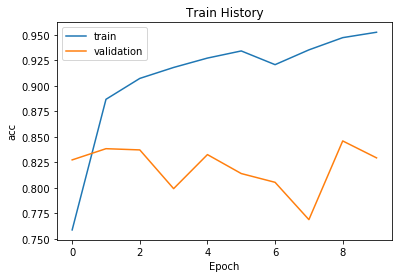

In [ ]:
show_train_history(train_history,'acc','val_acc')

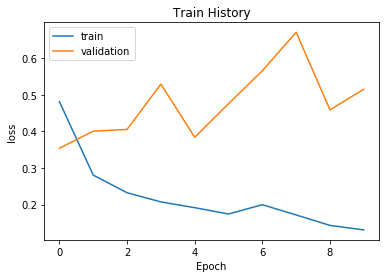

In [ ]:
show_train_history(train_history,'loss','val_loss')

# 評估模型準確率

In [ ]:
scores = model.evaluate(x_test, y_test, verbose=1)
scores[1]

24992/25000 [============================>.] - ETA: 0s

0.85792000000000002

# 預測機率

In [ ]:
probility=model.predict(x_test)

In [ ]:
probility[:10]

array([[ 0.99750549],
       [ 0.98419905],
       [ 0.95128489],
       [ 0.99300176],
       [ 0.98896539],
       [ 0.98833394],
       [ 0.99694985],
       [ 0.37184465],
       [ 0.99475718],
       [ 0.9976666 ]], dtype=float32)

In [ ]:
for p in probility[12500:12510]:
    print(p)

[ 0.05323071]
[ 0.00840928]
[ 0.00196839]
[ 0.03438321]
[ 0.0198016]
[ 0.00538083]
[ 0.10210149]
[ 0.00033639]
[ 0.00640061]
[ 0.02348054]


# 預測結果

In [ ]:
predict=model.predict_classes(x_test)

25000/25000 [==============================] - 29s    


In [ ]:
predict.shape

(25000, 1)

In [ ]:
predict_classes=predict.reshape(25000)
predict_classes

array([1, 1, 1, ..., 0, 0, 1])

# 查看預測結果

In [ ]:
SentimentDict={1:'正面的',0:'負面的'}
def display_test_Sentiment(i):
    print(test_text[i])
    print('標籤label:',SentimentDict[y_test[i]],'預測結果:',SentimentDict[predict_classes[i]])

In [ ]:
display_test_Sentiment(2)

As a recreational golfer with some knowledge of the sport's history, I was pleased with Disney's sensitivity to the issues of class in golf in the early twentieth century. The movie depicted well the psychological battles that Harry Vardon fought within himself, from his childhood trauma of being evicted to his own inability to break that glass ceiling that prevents him from being accepted as an equal in English golf society. Likewise, the young Ouimet goes through his own class struggles, being a mere caddie in the eyes of the upper crust Americans who scoff at his attempts to rise above his standing. What I loved best, however, is how this theme of class is manifested in the characters of Ouimet's parents. His father is a working-class drone who sees the value of hard work but is intimidated by the upper class; his mother, however, recognizes her son's talent and desire and encourages him to pursue his dream of competing against those who think he is inferior.Finally, the golf scenes

In [ ]:
display_test_Sentiment(3)

I saw this film in a sneak preview, and it is delightful. The cinematography is unusually creative, the acting is good, and the story is fabulous. If this movie does not do well, it won't be because it doesn't deserve to. Before this film, I didn't realize how charming Shia Lebouf could be. He does a marvelous, self-contained, job as the lead. There's something incredibly sweet about him, and it makes the movie even better. The other actors do a good job as well, and the film contains moments of really high suspense, more than one might expect from a movie about golf. Sports movies are a dime a dozen, but this one stands out. This is one I'd recommend to anyone.
標籤label: 正面的 預測結果: 正面的


In [ ]:
predict_classes[12500:12510]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
display_test_Sentiment(12500)

Once again Mr. Costner has dragged out a movie for far longer than necessary. Aside from the terrific sea rescue sequences, of which there are very few I just did not care about any of the characters. Most of us have ghosts in the closet, and Costner's character are realized early on, and then forgotten until much later, by which time I did not care. The character we should really care about is a very cocky, overconfident Ashton Kutcher. The problem is he comes off as kid who thinks he's better than anyone else around him and shows no signs of a cluttered closet. His only obstacle appears to be winning over Costner. Finally when we are well past the half way point of this stinker, Costner tells us all about Kutcher's ghosts. We are told why Kutcher is driven to be the best with no prior inkling or foreshadowing. No magic here, it was all I could do to keep from turning it off an hour in.
標籤label: 負面的 預測結果: 負面的


In [ ]:
#預測新的影評

In [ ]:
input_text='''
Oh dear, oh dear, oh dear: where should I start folks. I had low expectations already because I hated each and every single trailer so far, but boy did Disney make a blunder here. I'm sure the film will still make a billion dollars - hey: if Transformers 11 can do it, why not Belle? - but this film kills every subtle beautiful little thing that had made the original special, and it does so already in the very early stages. It's like the dinosaur stampede scene in Jackson's King Kong: only with even worse CGI (and, well, kitchen devices instead of dinos).
The worst sin, though, is that everything (and I mean really EVERYTHING) looks fake. What's the point of making a live-action version of a beloved cartoon if you make every prop look like a prop? I know it's a fairy tale for kids, but even Belle's village looks like it had only recently been put there by a subpar production designer trying to copy the images from the cartoon. There is not a hint of authenticity here. Unlike in Jungle Book, where we got great looking CGI, this really is the by-the-numbers version and corporate filmmaking at its worst. Of course it's not really a "bad" film; those 200 million blockbusters rarely are (this isn't 'The Room' after all), but it's so infuriatingly generic and dull - and it didn't have to be. In the hands of a great director the potential for this film would have been huge.
Oh and one more thing: bad CGI wolves (who actually look even worse than the ones in Twilight) is one thing, and the kids probably won't care. But making one of the two lead characters - Beast - look equally bad is simply unforgivably stupid. No wonder Emma Watson seems to phone it in: she apparently had to act against an guy with a green-screen in the place where his face should have been.
'''

In [ ]:
input_seq = token.texts_to_sequences([input_text])

In [ ]:
len(input_seq[0] )

297

In [ ]:
pad_input_seq  = sequence.pad_sequences(input_seq , maxlen=380)

In [ ]:
len(pad_input_seq[0])

380

In [ ]:
predict_result=model.predict_classes(pad_input_seq)

1/1 [==============================] - 0s


In [ ]:
predict_result

array([[0]])

In [ ]:
predict_result[0][0]

0

In [ ]:
SentimentDict[predict_result[0][0]]

'負面的'

In [ ]:
def predict_review(input_text):
    input_seq = token.texts_to_sequences([input_text])
    pad_input_seq  = sequence.pad_sequences(input_seq , maxlen=380)
    predict_result=model.predict_classes(pad_input_seq)
    print(SentimentDict[predict_result[0][0]])

In [ ]:
#http://www.imdb.com/title/tt2771200/
#http://www.imdb.com/title/tt2771200

In [ ]:
predict_review('''
It's hard to believe that the same talented director who made the influential cult action classic The Road Warrior had anything to do with this disaster.
Road Warrior was raw, gritty, violent and uncompromising, and this movie is the exact opposite. It's like Road Warrior for kids who need constant action in their movies.
This is the movie. The good guys get into a fight with the bad guys, outrun them, they break down in their vehicle and fix it. Rinse and repeat. The second half of the movie is the first half again just done faster.
The Road Warrior may have been a simple premise but it made you feel something, even with it's opening narration before any action was even shown. And the supporting characters were given just enough time for each of them to be likable or relatable.
In this movie there is absolutely nothing and no one to care about. We're supposed to care about the characters because... well we should. George Miller just wants us to, and in one of the most cringe worthy moments Charlize Theron's character breaks down while dramatic music plays to try desperately to make us care.
Tom Hardy is pathetic as Max. One of the dullest leading men I've seen in a long time. There's not one single moment throughout the entire movie where he comes anywhere near reaching the same level of charisma Mel Gibson did in the role. Gibson made more of an impression just eating a tin of dog food. I'm still confused as to what accent Hardy was even trying to do.
I was amazed that Max has now become a cartoon character as well. Gibson's Max was a semi-realistic tough guy who hurt, bled, and nearly died several times. Now he survives car crashes and tornadoes with ease?
In the previous movies, fuel and guns and bullets were rare. Not anymore. It doesn't even seem Post-Apocalyptic. There's no sense of desperation anymore and everything is too glossy looking. And the main villain's super model looking wives with their perfect skin are about as convincing as apocalyptic survivors as Hardy's Australian accent is. They're so boring and one-dimensional, George Miller could have combined them all into one character and you wouldn't miss anyone.
Some of the green screen is very obvious and fake looking, and the CGI sandstorm is laughably bad. It wouldn't look out of place in a Pixar movie.
There's no tension, no real struggle, or any real dirt and grit that Road Warrior had. Everything George Miller got right with that masterpiece he gets completely wrong here.
''')

1/1 [==============================] - 0s
負面的


In [ ]:
predict_review('''
Sure, I'm a huge film snob who (on the surface) only likes artsy-fartsy foreign films from before the 60's, but that hasn't stopped me from loving Disney's Beauty & The Beast; in fact, it's probably my favorite American animated film and is easily Disney's finest work. It's beautiful, it's breathtaking, it's warm, it's hilarious, it's captivating, and, in Disney fashion, it's magical. When I learned that Disney would be remaking their classic films, B&TB was undeniably the best wrapped package. How could they go wrong?
Oh man, they went wrong.
First thing's first: this film is so flat. The directing was dull and uninteresting throughout the entire film and it honestly felt like one of the Twilight sequels...and then I looked it up and found out that, yes, director Bill Condon was the man behind Breaking Dawn parts 1 & 2. Every shot looks bored and uninterested, which contrasts heavily with the original animated film that was constantly popping with vibrancy. The script too is boring because it's almost a complete remake of the original, though I guess most people won't mind that.
Next: the CGI is horrid. Although I didn't care for The Jungle Book from last year, I could at least admit that the CGI was breathtaking. The same cant be said for this film. Characters like Lumière, Cogsworth, Mrs Potts, and most of the cursed appliances have very strange, lifeless faces that are pretty off putting to be looking at for such a long time. All of the sets too look artificial and fake, especially the town towards the beginning. However, the biggest offender is easily and infuriatingly the character that mattered most: The Beast. The CGI on the Beast's face is so distracting that it completely takes you out of the film. His eyes are completely devoid of soul, and his mouth is a gaping video game black hole of fiction. Klaus Kinski looked much better in the Faerie Tale Theatre episode of Beauty & The Beast, and that was a 1984 TV show episode. But do you know why it looked better? Because it was an actual face with actual eyes, not some video game computerized synthetic monstrosity. When will studios learn that practical effects will always top CGI?
Finally: wasted casting. Emma Watson is beautiful, but she's no Belle. She is completely devoid of the warmth and humanity that made the animated Belle so beloved. Instead, she is cold and heartless throughout most of the film. Kevin Kline is 100% wasted and does nothing except look old. Ian McKellan, Ewan McGregor, Emma Thompson, and even Dan Stevens as the Beast are very expendable and could've been played by anyone else. The only good characters are Gaston and LeFou, mostly because they are fun and played by actors who breathe new life into their original shapes. If anything, this film should've been about Gaston and LeFou, but that would never happen because that would mean Disney couldn't cater to blind nostalgic 90's kids.
Overall, this film is a complete bore. It could've been better if even the special effects were good, but the CGI in particular is horrendous. I'm all for Disney remaking their nostalgia- catering 90's films, but they need to be interesting. This film, sadly, is not. Even the Christmas sequel is better than this film because it's at least something.
''')

1/1 [==============================] - 0s
負面的


In [ ]:
predict_review('''
I was really looking forward to this film. Not only has Disney recently made excellent live-action versions of their animated masterpieces (Jungle Book, Cinderella), but the cast alone (Emma Watson, Ian McKellen, Kevin Kline) already seemed to make this one a sure hit. Well, not so much as it turns out.
Some of the animation is fantastic, but because characters like Cogsworth (the clock), Lumière (the candelabra) and Chip (the little tea cup) now look "realistic", they lose a lot of their animated predecessors' charm and actually even look kind of creepy at times. And ironically - unlike in the animated original - in this new realistic version they only have very limited facial expressions (which is a creative decision I can't for the life of me understand).
Even when it works: there can be too much of a good thing. The film is overstuffed with lush production design and cgi (which is often weirdly artificial looking though) but sadly lacking in charm and genuine emotion. If this were a music album, I'd say it is "over-produced" and in need of more soul and swing. The great voice talent in some cases actually seems wasted, because it drowns in a sea of visual effects that numbs all senses. The most crucial thing that didn't work for me, though, is the Beast. He just never looks convincing. The eyes somehow don't look like real eyes and they're always slightly off.
On the positive side, I really liked Gaston, and the actor who played him, Luke Evans, actually gave the perhaps most energized performance of all. Kevin Kline as Belle's father has little to do but to look fatherly and old, but he makes the most of his part. Speaking of Belle, now that I've seen the film, I think her role was miscast. I think someone like Rachel McAdams would actually have been a more natural, lively and perhaps a bit more feisty Belle than Emma Watson.
If you love the original, you might want to give this one a pass, it's really not that good (although at least the songs were OK). Also, I'd think twice before bringing small children; without cute animated faces, all those "realistic" looking creatures and devices can be rather frightening for a child. ''')

1/1 [==============================] - 0s
正面的


In [ ]:
predict_review('''
Up front: I'm probably not the right audience for this film. I only went because I was invited, and I wouldn't have gone to check this one out otherwise.
Firstly, some of the production values are really beautiful and reminded me of the animated classic in a good way. Also, the voice cast for the clock and the kitchen devices are great.
Secondly, the actors, well... this may sound kind of harsh, but I've never seen Emma Watson act so stiff in a movie. Her performance is wooden, which is pretty bad considering she's supposed to be the heart of the film. Also, she probably won't start a singing career anytime soon.
Thirdly (and most importantly), Beast. That's where they really dropped the ball. Giving him a lifeless CGI face was an unforgivable mistake, and it's such a constant distraction that I could never really get into the movie.
Overall, I'm afraid I wouldn't recommend this movie, at least not to adults. I'm sure most kids would enjoy it though, and it's not really a bad film: just a very mediocre one. 6 stars out of 10.
''')

1/1 [==============================] - 0s
負面的


In [ ]:
predict_review('''
Full disclosure, I didn't think the first movie was as bad as it was made out to be. It wasn't good in almost any sense, but it was to be expected given the combination of source material, resources and constraints.
That said, this sequel is 20x better than the first. Having established the characters in the first movie, the actors seem to be able to act now comfortably in their parts. The story becomes much more nuanced with plenty of dynamics on the go.
SPOILERS from now on
Can they maintain a "vanilla" relationship? Is he going to become controlling again and ruin things? Will she let it get out of control and ruin things also or stay on it? Who is that stalky girl and what happened to her exactly? what about his mother? and that ex of his? Will something occur with her infatuated boss?
On top of all of this, I realised while watching that the series was never about a bizarre sadist control freak, it's actually about all men and the story of a woman trying to find the balance between accepting or desiring the dominant behaviour of the male archetype and maintaining strength and independence in such a relationship.
While of course the fact that he is rich, while possibly relating to the power struggle, looks like it is going to be more and more used for generating further drama. The romance is much more evident in this movie to/
''')

1/1 [==============================] - 0s
正面的


# serialize model to JSON

In [ ]:
model_json = model.to_json()
with open("SaveModel/Imdb_RNN_model.json", "w") as json_file:
    json_file.write(model_json)

model.save_weights("SaveModel/Imdb_RNN_model.h5")
print("Saved model to disk")

Saved model to disk
